# Session 7: Continuous Outcomes & Robust Models

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/07_continuous_outcomes_robust_models.ipynb)

In applied research, choosing a likelihood is a substantive scientific hypothesis about the continuous measurement process. In this laboratory, we examine Simon Newcomb's historical speed-of-light measurements (1882) to compare Gaussian and Student-$t$ models, audit targeted posterior predictive checks, and evaluate robustness without subjective outlier deletion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
import pymc as pm

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
rng = np.random.default_rng(2026)

# Simon Newcomb's 66 measurements of light passage time deviations (nanoseconds)
newcomb_data = np.array([
    28, 26, 33, 24, 34, -44, 27, 16, 40, -2, 29, 22, 24, 21, 25, 30,
    23, 29, 31, 19, 24, 20, 36, 32, 25, 28, 25, 28, 28, 27, 30, 27,
    26, 36, 26, 30, 22, 28, 23, 27, 27, 28, 27, 31, 27, 26, 33, 26,
    32, 32, 24, 39, 28, 24, 25, 32, 25, 29, 27, 28, 29, 16, 23
])
print(f"Newcomb dataset size: {len(newcomb_data)} measurements")
print(f"Sample Mean: {newcomb_data.mean():.2f}, Sample SD: {newcomb_data.std(ddof=1):.2f}, Min: {newcomb_data.min()}")

Newcomb dataset size: 63 measurements
Sample Mean: 25.73, Sample SD: 10.72, Min: -44


## 1. Fitting the Normal Baseline vs. Robust Student-$t$ Model in PyMC

In [2]:
# Model 1: Gaussian Baseline
with pm.Model() as normal_model:
    mu = pm.Normal("mu", mu=25.0, sigma=15.0)
    sigma = pm.HalfNormal("sigma", sigma=15.0)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=newcomb_data)
    idata_norm = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True)
    ppc_norm = pm.sample_posterior_predictive(idata_norm, random_seed=2026)

# Model 2: Robust Student-t
with pm.Model() as student_model:
    mu = pm.Normal("mu", mu=25.0, sigma=15.0)
    sigma = pm.HalfNormal("sigma", sigma=15.0)
    nu = pm.Gamma("nu", alpha=2.0, beta=0.1)  # Prior concentrating on heavy tails
    y_obs = pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=newcomb_data)
    idata_student = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True)
    ppc_student = pm.sample_posterior_predictive(idata_student, random_seed=2026)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


...

NUTS: [mu, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Sampling: [y_obs]


Output()

## 2. Comparing Posterior Estimates and Targeted PPC (Replicated Minimum)

=== Normal Baseline Model ===
         mean     sd  hdi_3%  hdi_97%  r_hat
mu     25.723  1.388  23.183   28.344    1.0
sigma  10.890  0.971   9.083   12.658    1.0

=== Robust Student-t Model ===
         mean     sd  hdi_3%  hdi_97%  r_hat
mu     27.094  0.544  26.109   28.170    1.0
sigma   3.500  0.600   2.426    4.616    1.0
nu      2.334  0.774   1.224    3.883    1.0


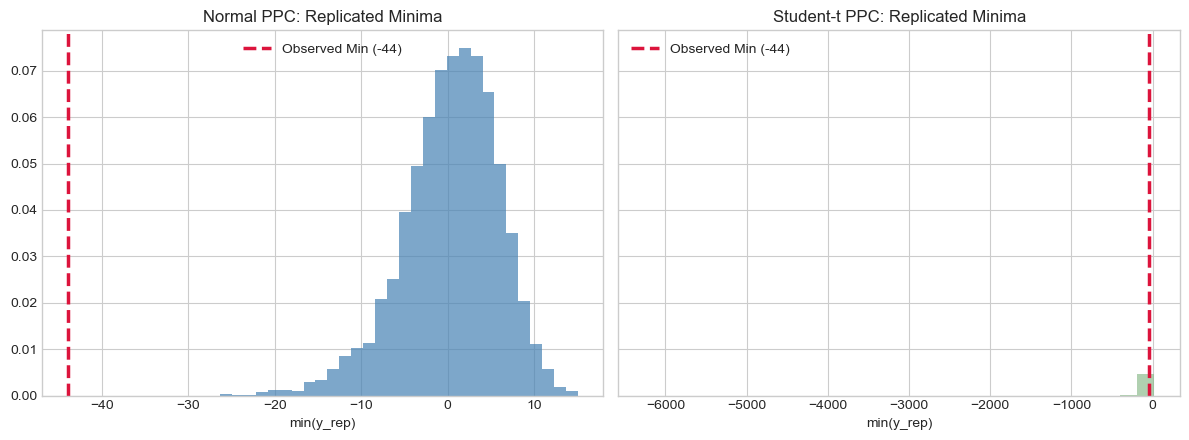

In [3]:
summary_norm = az.summary(idata_norm, var_names=["mu", "sigma"])
summary_t = az.summary(idata_student, var_names=["mu", "sigma", "nu"])

print("=== Normal Baseline Model ===")
print(summary_norm[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])
print("\n=== Robust Student-t Model ===")
print(summary_t[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])

# Targeted Posterior Predictive Check: Replicated Minima
rep_min_norm = ppc_norm.posterior_predictive["y_obs"].values.min(axis=-1).flatten()
rep_min_t = ppc_student.posterior_predictive["y_obs"].values.min(axis=-1).flatten()
obs_min = newcomb_data.min()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ax1.hist(rep_min_norm, bins=30, color="steelblue", alpha=0.7, density=True)
ax1.axvline(obs_min, color="crimson", lw=2.5, ls="--", label=f"Observed Min ({obs_min})")
ax1.set_title("Normal PPC: Replicated Minima")
ax1.set_xlabel("min(y_rep)")
ax1.legend()

ax2.hist(rep_min_t, bins=30, color="darkseagreen", alpha=0.7, density=True)
ax2.axvline(obs_min, color="crimson", lw=2.5, ls="--", label=f"Observed Min ({obs_min})")
ax2.set_title("Student-t PPC: Replicated Minima")
ax2.set_xlabel("min(y_rep)")
ax2.legend()
plt.tight_layout()
plt.show()